# Practical Work 3

## Loading the packages

In [20]:
import numpy as np
import matplotlib.pyplot as pl ## hello

## The Dataset


In [21]:
%pip install ipympl

/home/yomaru/HEIG/arn/lab3/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
import pandas as pd

 # Change this to any folder where data is if needed
mouse1 = pd.read_csv('EEG_mouse_data_1.csv')
mouse2 = pd.read_csv('EEG_mouse_data_2.csv')
dataset = pd.concat([mouse1, mouse2])
dataset
test_data = pd.read_csv('EEG_mouse_data_test.csv')

<font color="red">**For it to work on Colab, you will need to reload your session (Exécution -> redémarrer la session)**</font>

<font color="orange">**Make sure to put a large amount of points otherwise the cross validation folds will be really small**</font>

## Show the dataset

In [23]:
dataset = np.array(dataset)
dataset
test_data = np.array(test_data)

In [24]:
input_data = dataset[:, 1:26].astype(float)
input_data =  2 * (input_data - input_data.min()) / (input_data.max() - input_data.min()) - 1  # Normalize
output_data = np.where(dataset[:, 0] == 'w', 1, 0)

test_input_data = test_data[:, 1:26].astype(float)
test_input_data = 2 * (test_input_data - test_input_data.min()) / (test_input_data.max() - test_input_data.min()) - 1
test_output_data = np.where(test_data[:, 0] == 'w', 1, 0)

In [25]:
input_data

array([[-0.99107248, -0.98663234, -0.9874398 , ..., -0.99872009,
        -0.99816478, -0.9996605 ],
       [-0.99041434, -0.99063093, -0.98921035, ..., -0.99913124,
        -0.99972812, -0.99919762],
       [-0.98942059, -0.92487143, -0.96632692, ..., -0.9996973 ,
        -0.99963327, -0.99976717],
       ...,
       [-0.984127  , -0.97212774, -0.96922396, ..., -0.99988904,
        -0.99988364, -0.99978771],
       [-0.9874115 , -0.9866873 , -0.98064759, ..., -0.99920848,
        -0.99935931, -0.99906689],
       [-0.99653926, -0.99425444, -0.98944188, ..., -0.996399  ,
        -0.99929353, -0.9987015 ]], shape=(40863, 25))

In [26]:
output_data

array([0, 0, 0, ..., 1, 1, 1], shape=(40863,))

In [27]:
# Check data balance
unique, counts = np.unique(output_data, return_counts=True)
for label, count in zip(unique, counts):
    state = "Sleep" if label == 0 else "Awake"
    print(f"{state}: {count} samples ({count/len(output_data)*100:.1f}%)")


Sleep: 16503 samples (40.4%)
Awake: 24360 samples (59.6%)


In [28]:
%matplotlib inline

<Figure size 640x480 with 0 Axes>

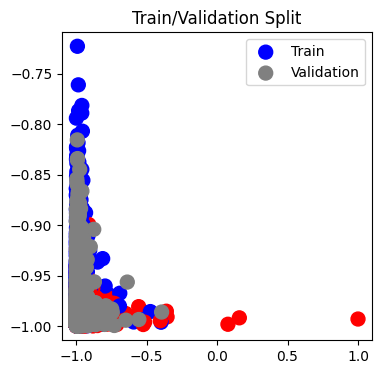

In [29]:
import keras
from keras import layers
from sklearn.model_selection import train_test_split

pl.clf()

keras.utils.set_random_seed(123)

# Split training data into train and validation (e.g., 80/20)
train_input, val_input, train_output, val_output = train_test_split(
    input_data, output_data, test_size=0.2, random_state=42
)

# Plot the split
pl.figure(figsize=(4,4))
pl.scatter(train_input[:,0], train_input[:,1], c=[(['b', 'r'])[int(d>0)] for d in train_output], s=100, label='Train')
pl.scatter(val_input[:,0], val_input[:,1], c=[(['gray', 'gray'])[int(d>0)] for d in val_output], s=100, label='Validation')
pl.title('Train/Validation Split')
pl.legend()
pl.show()

In [30]:
def create_model():
  # 25 inputs (EEG features)
  # 2 hidden nodes
  # 1 output

  mlp = keras.Sequential([
      layers.Input(shape=(25,)),
      layers.Dense(12, activation="relu"), # Try different numbers of hidden neurons here (e.g. 2, 4, 8, 32, 128)
      layers.Dense(1, activation="sigmoid"),
  ])

  # Experiment with hyperparameters here:
  # momentum: [0, 0.8, 0.9, 0.99]
  # learning_rate: [0.1, 0.01, 0.001, 0.0001]
  mlp.compile(
      optimizer=keras.optimizers.SGD(learning_rate=0.1, momentum=0.9),
      loss="mse",
  )

  return mlp

mlp = create_model()
mlp.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 12)             │           312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 325 (1.27 KB)

 Trainable params: 325 (1.27 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
mlp = create_model()

history = mlp.fit(
    x=train_input, y=train_output,
    validation_data=(val_input, val_output),
    epochs=200,
    batch_size=16
)


Epoch 1/200
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.2419 - val_loss: 0.2413
Epoch 2/200
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.2415 - val_loss: 0.2413
Epoch 3/200
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2415 - val_loss: 0.2413
Epoch 4/200
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2415 - val_loss: 0.2413
Epoch 5/200
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2415 - val_loss: 0.2413
Epoch 6/200
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.2415 - val_loss: 0.2413
Epoch 7/200
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2415 - val_loss: 0.2413
Epoch 8/200
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2415 - val_loss: 0.2413
Epoch 9/200
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.2415 - val_loss: 0.2413
Epoch 10/200
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2415 - val_loss: 0.2413
Epoch 11/200
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.2415 - val_loss: 0.2413
Epoch 12/200
2044/2

KeyboardInterrupt: 

# Plot training history

In [ ]:
pl.plot(history.history['loss'], label='Training Loss')
pl.plot(history.history['val_loss'], label='Validation Loss')
pl.xlabel('Epochs')
pl.ylabel('Loss')
pl.legend()
pl.show()

# Performances

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns

def plot_confusion_matrix(confusion_matrix, title):
    # Plot confusion matrix
    pl.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix.astype(int), annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Sleep", "Awake"], yticklabels=["Sleep", "Awake"])
    pl.title(title)
    pl.xlabel('Predicted')
    pl.ylabel('True')
    pl.show()

# Validation performance
val_predictions = (mlp.predict(val_input) > 0.5).astype(int)
val_cm = confusion_matrix(val_output, val_predictions)
val_f1 = f1_score(val_output, val_predictions)
plot_confusion_matrix(val_cm, 'Validation Confusion Matrix')
print(f"Validation F1 Score: {val_f1}")

# Test set performance
test_predictions = (mlp.predict(test_input_data) > 0.5).astype(int)
test_cm = confusion_matrix(test_output_data, test_predictions)
test_f1 = f1_score(test_output_data, test_predictions, average='micro')
plot_confusion_matrix(test_cm, 'Test Confusion Matrix')
print(f"Test F1 Score: {test_f1}")

# Exercise

Please try changing hyperparameters (number of neurons, number of layers, learning rate, momentum, number of epochs...) and observe the impact it has on training and validation loss, convergence, and computation time. For instance, observe if there's overfitting if you put a high number (i.e. 128) of neurons in the hidden layer.

You can also experiment with different datasets (clear separation between classes, unbalanced...)
